In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# optional styling
sns.set_style("whitegrid")

In [2]:
df=pd.read_csv("../data/swiggy_file.csv")
df.head()

,Restaurant Name,Cuisine,Rating,Number of Ratings,Average Price,Number of Offers,Offer Name,Area,Pure Veg,Location
0,La Pino'Z Pizza,"Pizzas, Pastas",4.0,10+ ratings,₹250 for two,2,FLAT DEAL\nFLAT ₹125 OFF\nUSE FLAT125ABOVE ₹69...,LALA LAJPAT RAI MARKET,No,Abohar
1,The Second Wife,"Indian, North Indian",3.6,50+ ratings,₹250 for two,2,"30% OFF UPTO ₹75\nUSE TRYNEWABOVE ₹149, FLAT ₹...",Central Abohar,No,Abohar
2,Tasty Bites,"Italian, Beverages",3.8,10+ ratings,₹200 for two,1,FLAT ₹120 OFF\nUSE AXIS120ABOVE ₹500,Central Abohar,Yes,Abohar
3,Food Studio,"Pizzas, Burgers",3.5,8 ratings,₹49 for two,5,"50% OFF UPTO ₹100\nUSE TRYNEWABOVE ₹129, FLAT ...",Central Abohar,Yes,Abohar
4,Roll Express,"Fast Food, Snacks",4.3,100+ ratings,₹200 for two,2,DEAL OF DAY\n10% OFF UPTO ₹40\nUSE STEALDEALAB...,Circular Road,No,Abohar


In [3]:
df.columns

Index(['Restaurant Name', 'Cuisine', 'Rating', 'Number of Ratings',
       'Average Price', 'Number of Offers', 'Offer Name', 'Area', 'Pure Veg',
       'Location'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140657 entries, 0 to 140656
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   Restaurant Name    140657 non-null  object
 1   Cuisine            140630 non-null  object
 2   Rating             140657 non-null  object
 3   Number of Ratings  126115 non-null  object
 4   Average Price      140657 non-null  object
 5   Number of Offers   140657 non-null  int64 
 6   Offer Name         138849 non-null  object
 7   Area               140655 non-null  object
 8   Pure Veg           140657 non-null  object
 9   Location           140657 non-null  object
dtypes: int64(1), object(9)
memory usage: 10.7+ MB


In [5]:
df['Rating']=pd.to_numeric(df['Rating'],errors='coerce')

In [6]:
df['Average Price'] = df['Average Price'].str.replace(r'[^0-9]', '', regex=True)
df['Average Price'] = pd.to_numeric(df['Average Price'], errors='coerce')

In [7]:
df['Number of Ratings']=df['Number of Ratings'].str.replace(',','')
df['Number of Ratings'] = pd.to_numeric(df['Number of Ratings'], errors='coerce')

In [8]:
df.isnull().sum()

Restaurant Name           0
Cuisine                  27
Rating                33719
Number of Ratings    140657
Average Price             0
Number of Offers          0
Offer Name             1808
Area                      2
Pure Veg                  0
Location                  0
dtype: int64

In [9]:
df = df.dropna(subset=['Cuisine', 'Rating'])

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 106938 entries, 0 to 140655
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Restaurant Name    106938 non-null  object 
 1   Cuisine            106938 non-null  object 
 2   Rating             106938 non-null  float64
 3   Number of Ratings  0 non-null       float64
 4   Average Price      106938 non-null  int64  
 5   Number of Offers   106938 non-null  int64  
 6   Offer Name         105751 non-null  object 
 7   Area               106936 non-null  object 
 8   Pure Veg           106938 non-null  object 
 9   Location           106938 non-null  object 
dtypes: float64(2), int64(2), object(6)
memory usage: 9.0+ MB


In [11]:
pizza_df = df[df['Cuisine'].str.contains("pizza", case=False, na=False)]

pizza_df.head()

,Restaurant Name,Cuisine,Rating,Number of Ratings,Average Price,Number of Offers,Offer Name,Area,Pure Veg,Location
0,La Pino'Z Pizza,"Pizzas, Pastas",4.0,NaN,250,2,FLAT DEAL\nFLAT ₹125 OFF\nUSE FLAT125ABOVE ₹69...,LALA LAJPAT RAI MARKET,No,Abohar
3,Food Studio,"Pizzas, Burgers",3.5,NaN,49,5,"50% OFF UPTO ₹100\nUSE TRYNEWABOVE ₹129, FLAT ...",Central Abohar,Yes,Abohar
9,Picado International Food,"Pizzas, Beverages",4.3,NaN,300,2,"40% OFF UPTO ₹80\nUSE TRYNEWABOVE ₹149, FLAT ₹...",Central Abohar,Yes,Abohar
11,Grill Master,"Pizzas, Indian",4.2,NaN,250,1,FLAT ₹120 OFF\nUSE AXIS120ABOVE ₹500,Abohar Locality,No,Abohar
12,PUBG Cafe,"Chinese, Pizzas",3.3,NaN,200,1,FLAT ₹120 OFF\nUSE AXIS120ABOVE ₹500,Central Abohar,Yes,Abohar


In [12]:
pizza_df.shape

(9045, 10)

In [13]:
pizza_df['Restaurant Name'].value_counts().head(10)

Restaurant Name
Domino'S Pizza                          211
Pizza Hut                               206
La Pino'Z Pizza                         151
Firangi Bake                             76
Oven Story Pizza - Standout Toppings     65
Chicago Pizza                            62
Laziz Pizza                              57
Pizza House                              34
Pizza Hub                                31
PizzaExpress                             26
Name: count, dtype: int64

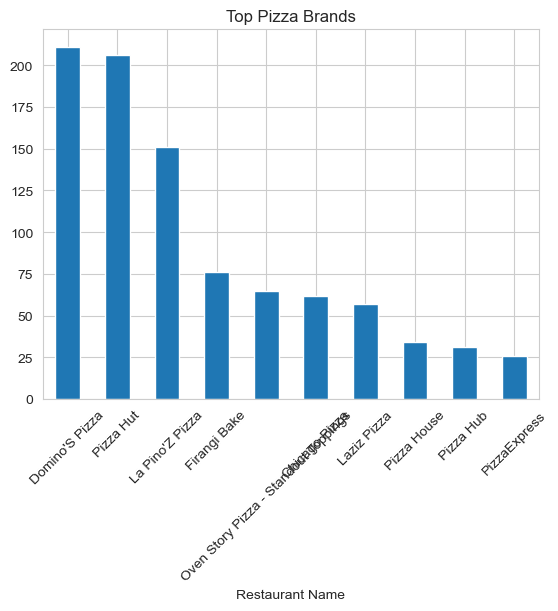

In [14]:
top_brands = pizza_df['Restaurant Name'].value_counts().head(10)

top_brands.plot(kind='bar')
plt.title("Top Pizza Brands")
plt.xticks(rotation=45)
plt.show()

In [15]:
dominos = pizza_df[pizza_df['Restaurant Name'].str.contains("domino", case=False, na=False)]
pizza_hut = pizza_df[pizza_df['Restaurant Name'].str.contains("pizza hut", case=False, na=False)]

print("Dominos Avg Rating:", dominos['Rating'].mean())
print("Pizza Hut Avg Rating:", pizza_hut['Rating'].mean())

Dominos Avg Rating: 4.219196428571428
Pizza Hut Avg Rating: 4.055263157894737


In [16]:
print("Dominos Avg Price:", dominos['Average Price'].mean())
print("Pizza Hut Avg Price:", pizza_hut['Average Price'].mean())

Dominos Avg Price: 393.08035714285717
Pizza Hut Avg Price: 343.55263157894734


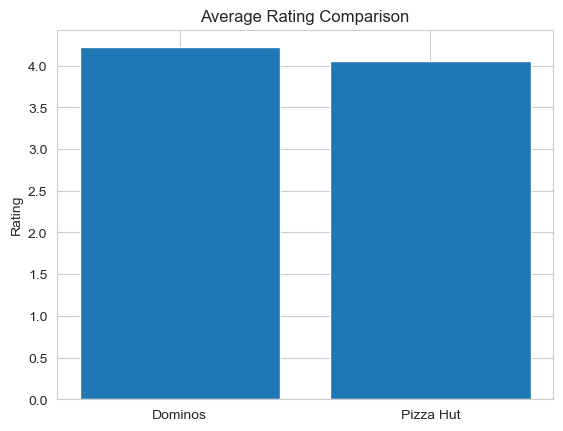

In [17]:
brands = ['Dominos', 'Pizza Hut']
ratings = [dominos['Rating'].mean(), pizza_hut['Rating'].mean()]

plt.bar(brands, ratings)
plt.title("Average Rating Comparison")
plt.ylabel("Rating")
plt.show()

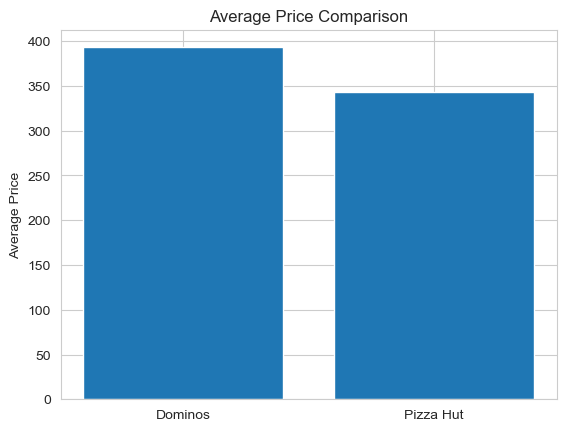

In [18]:
brands = ['Dominos', 'Pizza Hut']
prices = [dominos['Average Price'].mean(), pizza_hut['Average Price'].mean()]

plt.bar(brands, prices)
plt.title("Average Price Comparison")
plt.ylabel("Average Price")
plt.show()

Key Insights
1. Market Dominance
-Domino's has the highest number of outlets among pizza brands
-Indicates strong availability and reach
2. Rating Comparison
-Domino’s (4.22) is only slightly higher than Pizza Hut (4.05)
-Quality difference is minimal
3. Pricing Insight
-Domino’s is more expensive (~₹393 vs ₹343)
-Despite higher price, it still dominates
4. Core Conclusion
-Domino’s dominance is driven by availability, brand trust, and consistency rather than price advantage or significantly superior quality.

In [19]:
df.duplicated().sum()

np.int64(1074)

In [20]:
df = df.drop_duplicates()

In [21]:
brand_counts = pizza_df['Restaurant Name'].value_counts()

market_share = (brand_counts / brand_counts.sum()) * 100

market_share.head(10)

Restaurant Name
Domino'S Pizza                          2.332781
Pizza Hut                               2.277501
La Pino'Z Pizza                         1.669431
Firangi Bake                            0.840243
Oven Story Pizza - Standout Toppings    0.718629
Chicago Pizza                           0.685462
Laziz Pizza                             0.630182
Pizza House                             0.375898
Pizza Hub                               0.342731
PizzaExpress                            0.287452
Name: count, dtype: float64

In [22]:
print("Dominos Avg Offers:", dominos['Number of Offers'].mean())
print("Pizza Hut Avg Offers:", pizza_hut['Number of Offers'].mean())

Dominos Avg Offers: 4.044642857142857
Pizza Hut Avg Offers: 3.1096491228070176


In [23]:
pizza_df['Pure Veg'].value_counts()

Pure Veg
No     4754
Yes    4291
Name: count, dtype: int64

In [24]:
dominos['Pure Veg'].value_counts(normalize=True)
pizza_hut['Pure Veg'].value_counts(normalize=True)

Pure Veg
No     0.907895
Yes    0.092105
Name: proportion, dtype: float64

In [25]:
dominos['Location'].value_counts().head(10)

Location
Kanpur         6
Gorakhpur      3
Junagadh       3
Noida-1        2
Kolkata        2
Pune           2
Sikar          2
Kanchrapara    2
Ahmedabad      1
Amravati       1
Name: count, dtype: int64

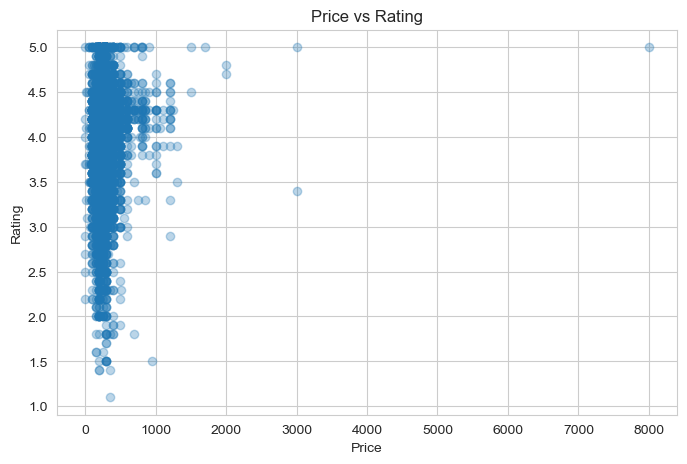

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(pizza_df['Average Price'], pizza_df['Rating'], alpha=0.3)
plt.xlabel("Price")
plt.ylabel("Rating")
plt.title("Price vs Rating")
plt.show()

In [27]:
pizza_df.groupby('Restaurant Name')['Location'].nunique().sort_values(ascending=False).head(10)

Restaurant Name
Domino'S Pizza                          208
Pizza Hut                               197
La Pino'Z Pizza                         151
Firangi Bake                             76
Oven Story Pizza - Standout Toppings     64
Chicago Pizza                            62
Laziz Pizza                              57
Pizza House                              33
Pizza Hub                                31
Pizza King                               26
Name: Location, dtype: int64

In [28]:
print("Dominos Cities:", dominos['Location'].nunique())
print("Pizza Hut Cities:", pizza_hut['Location'].nunique())

Dominos Cities: 210
Pizza Hut Cities: 203


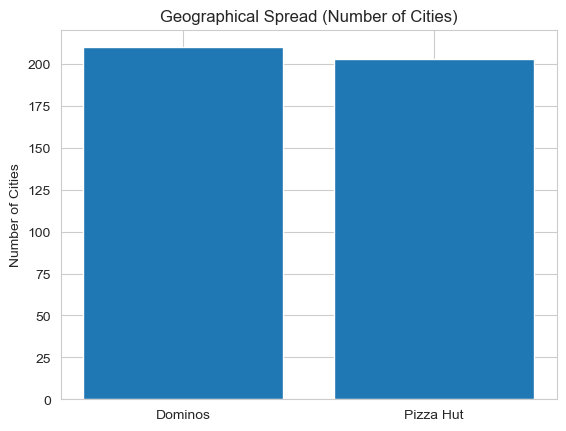

In [29]:
brands = ['Dominos', 'Pizza Hut']
cities = [dominos['Location'].nunique(), pizza_hut['Location'].nunique()]

plt.bar(brands, cities)
plt.title("Geographical Spread (Number of Cities)")
plt.ylabel("Number of Cities")
plt.show()

In [30]:
df.to_csv("cleaned_zomato_data.csv", index=False)

In [31]:
df.to_csv("cleaned_swiggy_data.csv", index=False)

In [32]:
pizza_df.to_csv("pizza_data.csv", index=False)

In [35]:
pizza_df[['Average Price', 'Rating']].corr()

,Average Price,Rating
Average Price,1.000000,0.118456
Rating,0.118456,1.000000


In [37]:
pizza_df['Restaurant Name'].value_counts().head(5)

Restaurant Name
Domino'S Pizza                          211
Pizza Hut                               206
La Pino'Z Pizza                         151
Firangi Bake                             76
Oven Story Pizza - Standout Toppings     65
Name: count, dtype: int64

In [39]:
dominos = pizza_df[pizza_df['Restaurant Name']=="Domino'S Pizza"].shape[0]
pizza_hut = pizza_df[pizza_df['Restaurant Name']=="Pizza Hut"].shape[0]

((dominos - pizza_hut) / pizza_hut) * 100

2.4271844660194173

In [42]:
brands = ["Domino'S Pizza", "Pizza Hut", "La Pino'Z Pizza"]

pizza_df[pizza_df['Restaurant Name'].isin(brands)] \
    .groupby('Restaurant Name')['Number of Offers'] \
    .mean()

Restaurant Name
Domino'S Pizza     4.014218
La Pino'Z Pizza    4.410596
Pizza Hut          3.072816
Name: Number of Offers, dtype: float64

In [44]:
pizza_df['Location'].nunique()

545

In [45]:
pizza_df[pizza_df['Restaurant Name']=="Domino'S Pizza"]['Location'].nunique()

208

In [46]:
pizza_df[pizza_df['Restaurant Name']=="Pizza Hut"]['Location'].nunique()

197